In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os

from pyarrow import feather

In [16]:
ITEM_ID = 26008           # Example item_id from sample_head.csv
STORE_ID = 6269        # Example store_id from sample_head.csv
DATA_PATH = '../dataset/data_andre.feather' # Adjust path if needed
TARGET_COL = 'value'
DATE_COL = 'date'

N_FORECAST = 1 
N_LOOKBACK = 30
N_FUTURE = 365
EPOCHS = 10            # Reduced epochs for quicker testing
BATCH_SIZE = 32
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [17]:
# -----------------------------------------------------------------------------
# DATA LOADING & PREPROCESSING
# -----------------------------------------------------------------------------
DATA_PATH = '../dataset/subset_set.feather'  # Adjust path if needed
print(f"Loading data from {DATA_PATH}...")
# Use pd.read_feather instead of feather.read_table to get a DataFrame directly
df_full = pd.read_feather(DATA_PATH)

print(f"Filtering for Item: {ITEM_ID}, Store: {STORE_ID}...")
# Filter for specific item and store
df = df_full[(df_full['item_id'] == ITEM_ID) & (df_full['store_id'] == STORE_ID)].copy()

# Reset index to avoid ambiguity if 'date' is also in the index
df = df.reset_index(drop=True)

# Ensure date is datetime and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL)

# Prepare target variable
# Using 'value' as the target (sales/demand)
# Updated to use ffill() directly as fillna(method='ffill') is deprecated
y = df[TARGET_COL].ffill().values.reshape(-1, 1)

df_full

Loading data from ../dataset/subset_set.feather...
Filtering for Item: 26008, Store: 6269...


,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,promo_value_GAS,...,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,store_id,date
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,26008,104,sprd btr mrgrn,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,2021-01-23
2021-01-23,921558,15,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,2021-01-23
2021-01-23,213626,85,milknplant based bevs,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,2021-01-23
2021-01-23,213625,44,milknplant based bevs,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,2021-01-23
2021-01-23,213624,40,milknplant based bevs,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,2021-01-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-22,213625,30,milknplant based bevs,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,2023-02-22
2023-02-22,213629,38,milknplant based bevs,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,2023-02-22
2023-02-22,921558,18,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,0.0,...,0,0.0,0,0.0,0,0.0,0,0.0,6269,2023-02-22


In [ ]:
# -----------------------------------------------------------------------------
# DATA LOADING & PREPROCESSING
# -----------------------------------------------------------------------------
DATA_PATH = '../dataset/subset_set.feather'  # Adjust path if needed
print(f"Loading data from {DATA_PATH}...")
# Use pd.read_feather instead of feather.read_table to get a DataFrame directly
df_full = pd.read_feather(DATA_PATH)

print(f"Filtering for Item: {ITEM_ID}, Store: {STORE_ID}...")
# Filter for specific item and store
df = df_full[(df_full['item_id'] == ITEM_ID) & (df_full['store_id'] == STORE_ID)].copy()

# Reset index to avoid ambiguity if 'date' is also in the index
df = df.reset_index(drop=True)

# Ensure date is datetime and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL)

# Prepare target variable
# Using 'value' as the target (sales/demand)
# Updated to use ffill() directly as fillna(method='ffill') is deprecated
y = df[TARGET_COL]



# -----------------------------------------------------------------------------
# DATA SPLITTING
# -----------------------------------------------------------------------------
# Define split sizes
n_train = 500
n_val = 100
n_test = 161

# Ensure the split adds up
assert n_train + n_val + n_test == len(y_scaled), f"Split sizes ({n_train}+{n_val}+{n_test}={n_train+n_val+n_test}) must equal total samples ({len(y_scaled)})"

print(f"Splitting data: Train={n_train}, Validation={n_val}, Test={n_test}")

# Split indices
train_data = y_scaled[:n_train]
val_data = y_scaled[n_train:n_train+n_val]
test_data = y_scaled[n_train+n_val:]

# Helper function to create sequences
def create_sequences(self):
        """Create pairs where input is all history from start to t, output is t+1"""
        X, y = [], []
        
        # For each point, use all history from start to that point
        for i in range(1, len(self.values)):
            x_seq = self.values[:i]  # All history from start to current point
            y_val = self.values[i]    # Next value to predict
            
            X.append(x_seq)
            y.append(y_val)
        
        return X, np.array(y, dtype=np.float32)

X_train, Y_train = create_sequences(train_data, N_LOOKBACK)

# Validation sequences (using history from train)
# We need `N_LOOKBACK` points before the validation set starts
val_extended = np.concatenate((train_data[-N_LOOKBACK:], val_data))
X_val, Y_val = create_sequences(val_extended, N_LOOKBACK)

# Test sequences (using history from val)
test_extended = np.concatenate((val_data[-N_LOOKBACK:], test_data))
X_test, Y_test = create_sequences(test_extended, N_LOOKBACK)

print(f"Train shapes: X={X_train.shape}, Y={Y_train.shape}")
print(f"Val shapes:   X={X_val.shape}, Y={Y_val.shape}")
print(f"Test shapes:  X={X_test.shape}, Y={Y_test.shape}")

# Convert to Tensors
X_train_tensor = torch.from_numpy(X_train).float().to(DEVICE)
Y_train_tensor = torch.from_numpy(Y_train).float().to(DEVICE)

X_val_tensor = torch.from_numpy(X_val).float().to(DEVICE)
Y_val_tensor = torch.from_numpy(Y_val).float().to(DEVICE)

X_test_tensor = torch.from_numpy(X_test).float().to(DEVICE)
Y_test_tensor = torch.from_numpy(Y_test).float().to(DEVICE)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loading data from ../dataset/subset_set.feather...
Filtering for Item: 26008, Store: 6269...
Dataset has 761 days. Using the first 761 days for the split.
Splitting data: Train=500, Validation=100, Test=161
Train shapes: X=(470, 30, 1), Y=(470, 1)
Val shapes:   X=(100, 30, 1), Y=(100, 1)
Test shapes:  X=(161, 30, 1), Y=(161, 1)


In [19]:
class LSTMForecaster(nn.Module):
    
    def __init__(self, input_size: int = 1, hidden_size: int = 128, num_layers: int = 2, 
                 forecast_horizon: int = None, dropout: float = 0.2):

        super(LSTMForecaster, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.input_size = input_size
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Output layer: predict single next value
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_out = out[:, -1, :]
        
        return self.fc(last_out)

Starting training...
Epoch [10/10], Train Loss: 0.0050, Val Loss: 0.0014


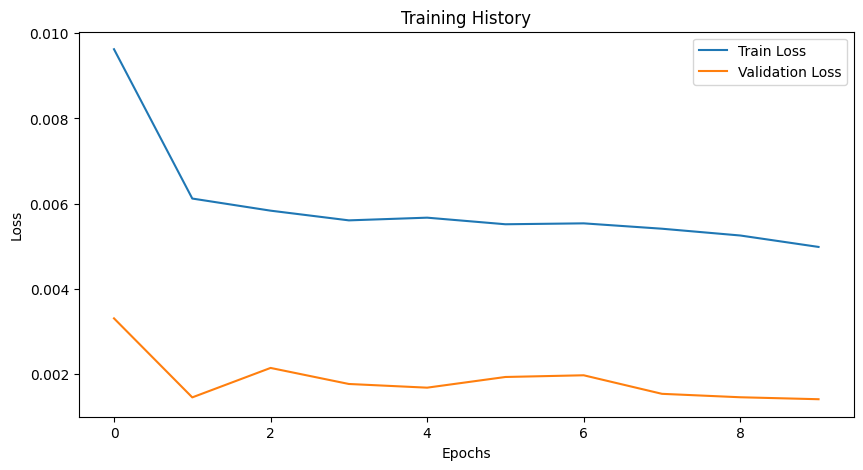

In [20]:
# Initialize model, loss, optimizer
model = LSTMForecaster(input_size=1, hidden_size=50, num_layers=2).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# -----------------------------------------------------------------------------
# TRAINING LOOP
# -----------------------------------------------------------------------------
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_Y.view(-1, 1)) # batch_Y shape might be (32, 1) or (32)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        
    train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_Y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_Y.view(-1, 1))
            epoch_val_loss += loss.item()
            
    val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

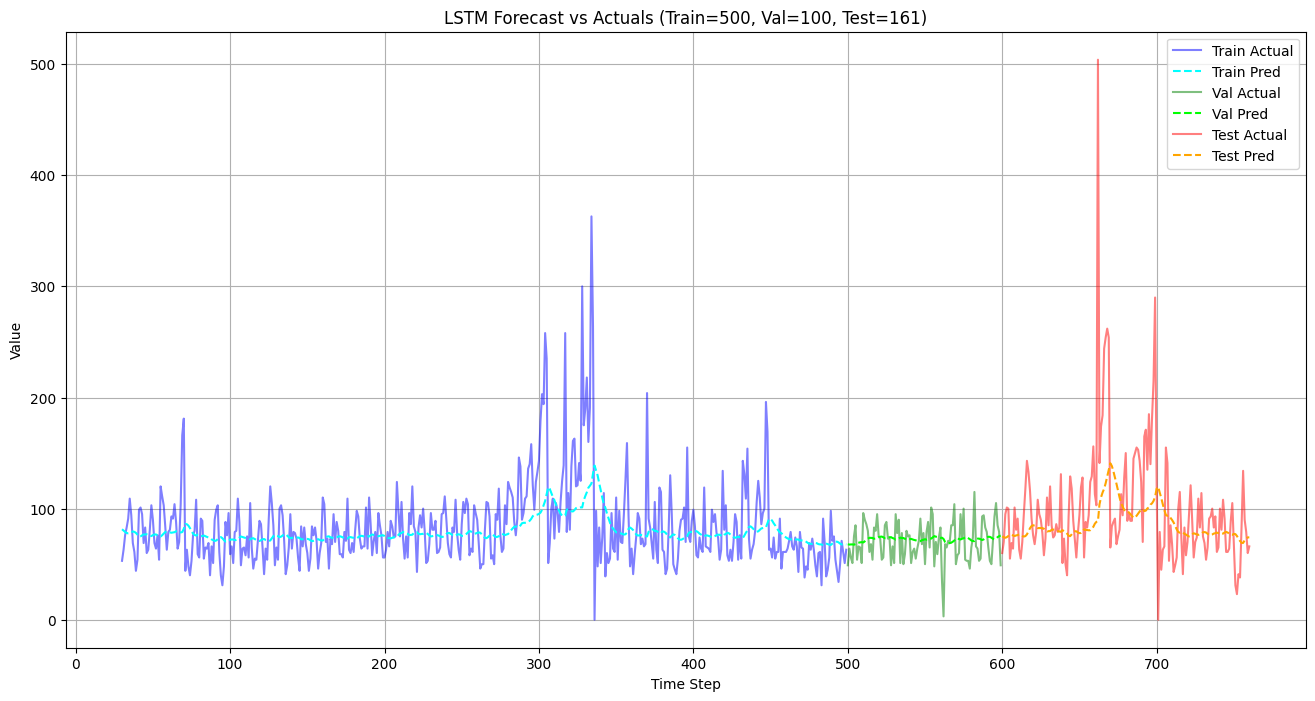

Test RMSE: 53.66


In [21]:
# -----------------------------------------------------------------------------
# EVALUATION & FORECASTING
# -----------------------------------------------------------------------------
model.eval()

# Generate predictions for all sets
with torch.no_grad():
    train_preds = model(X_train_tensor.to(DEVICE)).cpu().numpy().flatten()
    val_preds = model(X_val_tensor.to(DEVICE)).cpu().numpy().flatten()
    test_preds = model(X_test_tensor.to(DEVICE)).cpu().numpy().flatten()

# Inverse transform to original scale
train_preds_inv = scaler.inverse_transform(train_preds.reshape(-1, 1))
val_preds_inv = scaler.inverse_transform(val_preds.reshape(-1, 1))
test_preds_inv = scaler.inverse_transform(test_preds.reshape(-1, 1))

# Also inverse transform the actual values for comparison
train_actual_inv = scaler.inverse_transform(Y_train.reshape(-1, 1))
val_actual_inv = scaler.inverse_transform(Y_val.reshape(-1, 1))
test_actual_inv = scaler.inverse_transform(Y_test.reshape(-1, 1))

# Plotting
plt.figure(figsize=(16, 8))

# Construct a full timeline for visualization
# Note: The indices are relative to the split.
# Train: 0 to 500 (but first lookback points are skipped in X_train construction if using strictly train data...
# Wait, my create_sequences function:
# for i in range(lookback, len(data)):
#     X.append(data[i-lookback:i])
#     Y.append(data[i])
# So X_train corresponds to indices [lookback, ..., n_train-1] of the original train_data array.
# Length is n_train - lookback.
#
# But for val/test, I used 'extended' concatenation, so we have full n_val predictions.

# Train plot
train_range = range(N_LOOKBACK, n_train)
plt.plot(train_range, train_actual_inv, label='Train Actual', color='blue', alpha=0.5)
plt.plot(train_range, train_preds_inv, label='Train Pred', color='cyan', linestyle='--')

# Validation plot
val_range = range(n_train, n_train + n_val)
plt.plot(val_range, val_actual_inv, label='Val Actual', color='green', alpha=0.5)
plt.plot(val_range, val_preds_inv, label='Val Pred', color='lime', linestyle='--')

# Test plot
test_range = range(n_train + n_val, n_train + n_val + n_test)
plt.plot(test_range, test_actual_inv, label='Test Actual', color='red', alpha=0.5)
plt.plot(test_range, test_preds_inv, label='Test Pred', color='orange', linestyle='--')

plt.title(f'LSTM Forecast vs Actuals (Train={n_train}, Val={n_val}, Test={n_test})')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Calculate RMSE for Test Set
from sklearn.metrics import mean_squared_error
test_rmse = np.sqrt(mean_squared_error(test_actual_inv, test_preds_inv))
print(f"Test RMSE: {test_rmse:.2f}")